In [204]:
from typing import List

from qiskit.circuit.random import random_clifford_circuit
from qiskit import QuantumCircuit
from qiskit.circuit.library import RYGate, XGate, ZGate, HGate, IGate, CXGate, CZGate, SwapGate
from qiskit.quantum_info import Statevector

import numpy as np

In [29]:
GATES_LIST = ['x', 'z', 'h', 'cx', 'cz', 'swap', 'i']

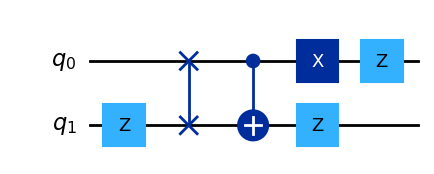

In [24]:
circ = random_clifford_circuit(num_qubits=2, num_gates=6, gates=GATES_LIST)
circ.draw(output='mpl')

---

In [105]:
# BASED ON: https://github.com/Qiskit/qiskit/blob/stable/2.5/qiskit/circuit/random/utils.py#L685-L753

In [206]:
class RandomCircuit:
    def __init__(self, seed:int=37):
        self._all_gates = {
            'x': lambda  : XGate(), 
            'z': lambda : ZGate(), 
            'h': lambda : HGate(), 
            'id': lambda : IGate(),  
            'cx': lambda : CXGate(), 
            'cz': lambda : CZGate(), 
            'swap': lambda : SwapGate(), 
            'ry':lambda theta: RYGate(theta)
        }
        self._two_qubit = ['cx', 'cz', 'swap']
        self._with_parameters = ['ry']

        self._low_param = 0
        self._high_param = 2*np.pi
        
        self._rng = np.random.default_rng(seed)

    def _get_angle(self) -> float:
        return self._rng.uniform(low=self._low_param,high=self._high_param,size=None)

    def _gate_num_qubits(self, gate:str) -> int:
        return int(gate in self._two_qubit)+1
        
    def _get_random_gates(self,num_gates:int)-> list[str]:
        return self._rng.choice(list(self._all_gates.keys()), num_gates)

    def _add_to_circuit(self, gates:List[str], qc:QuantumCircuit) -> None:
        num_qubits = qc.num_qubits
        for gate in gates:
            pos = self._rng.choice(range(num_qubits), self._gate_num_qubits(gate), replace=False).tolist()
            qc.append(
                self._all_gates[gate]() 
                if gate not in self._with_parameters 
                else self._all_gates[gate](self._get_angle())
            , pos, copy=False)

    def _add_barrier_at_the_end(self,qc:QuantumCircuit) -> None:
        if self._rng.random() <= 0.3:
            qc.barrier()
    
    def get_random_circuit(self, num_gates:int, num_qubits:int, add_barrier:bool=True, max_layers:int=5, min_layers:int=0) -> QuantumCircuit:
        qc = QuantumCircuit(num_qubits)
        
        gates = self._get_random_gates(num_gates)
        num_layers = self._rng.integers(min_layers,max_layers,1)[0]

        if not num_layers:
            self._add_to_circuit(gates, qc)
            self._add_barrier_at_the_end(qc)
            
        else:
            c = num_gates
            
            for _ in range(num_layers):
                layer_gates = self._rng.integers(0,c,1)[0]
                if not layer_gates:
                    continue

                selected_gates = self._rng.choice(gates,layer_gates,replace=False).tolist()
                self._add_to_circuit(selected_gates, qc)
                c -= len(selected_gates)

                if c <= 0:
                    self._add_barrier_at_the_end(qc)
                    break
                    
                qc.barrier()

            if c > 0:
                selected_gates = self._rng.choice(gates,c,replace=False).tolist()
                self._add_to_circuit(selected_gates, qc)
                self._add_barrier_at_the_end(qc)
        

        return qc
        

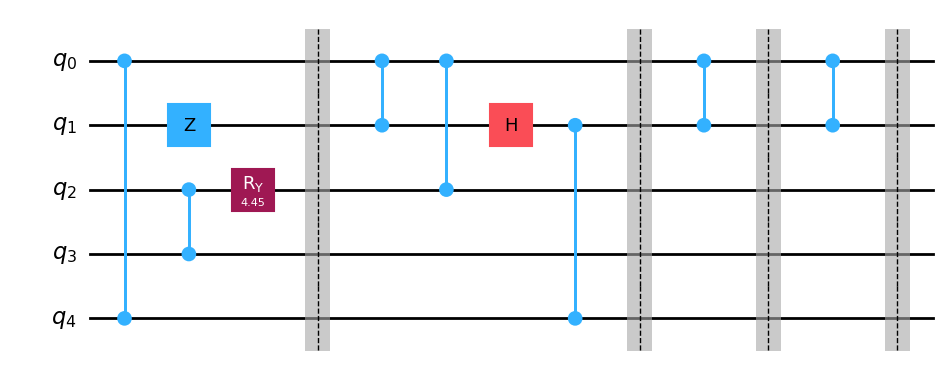

<IPython.core.display.Latex object>

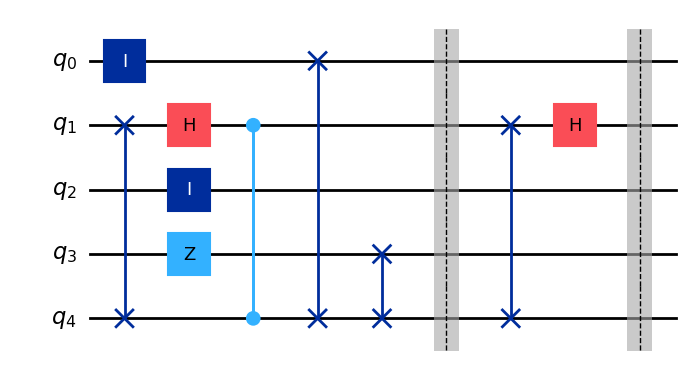

<IPython.core.display.Latex object>

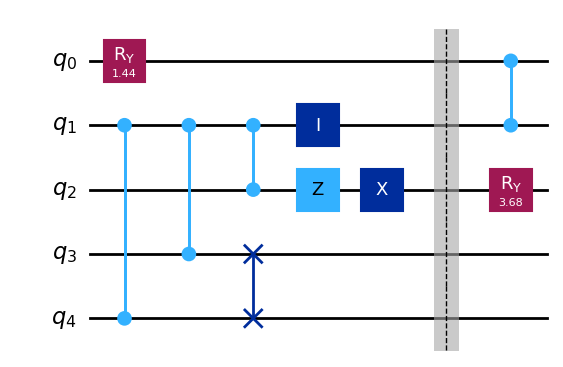

<IPython.core.display.Latex object>

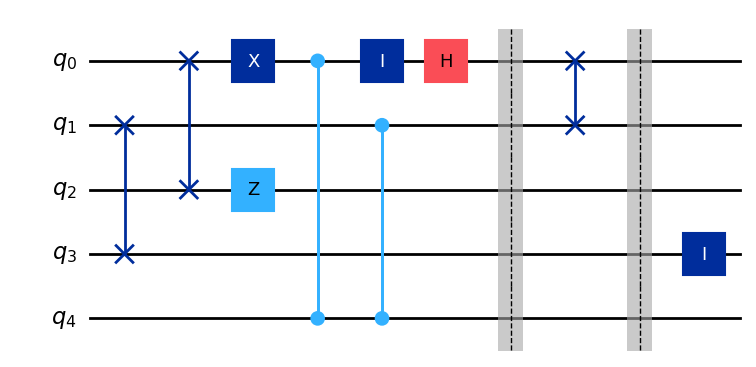

<IPython.core.display.Latex object>

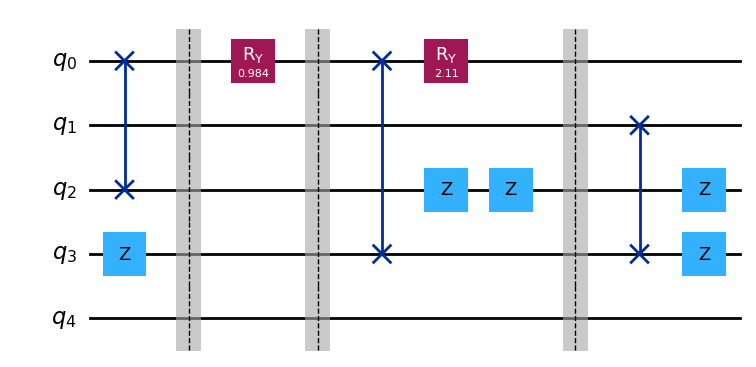

<IPython.core.display.Latex object>

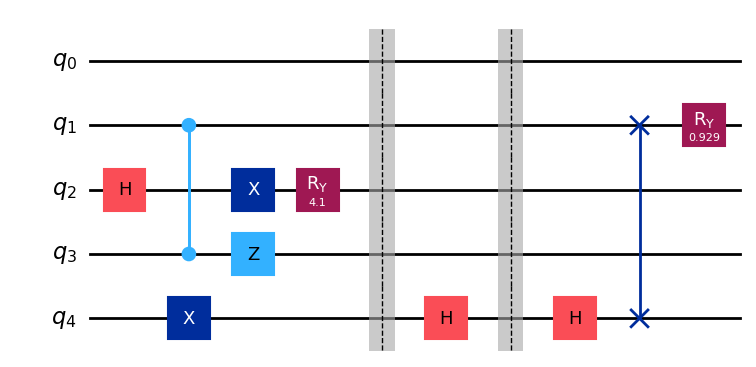

<IPython.core.display.Latex object>

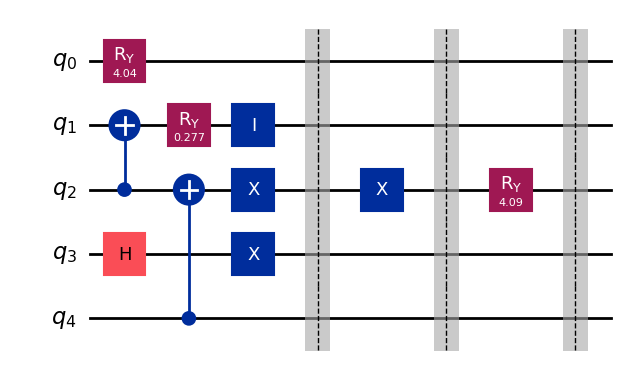

<IPython.core.display.Latex object>

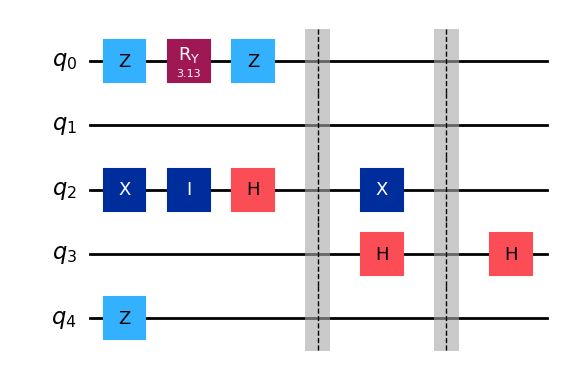

<IPython.core.display.Latex object>

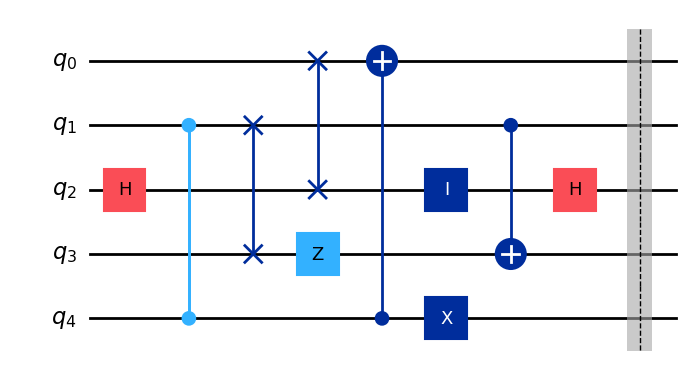

<IPython.core.display.Latex object>

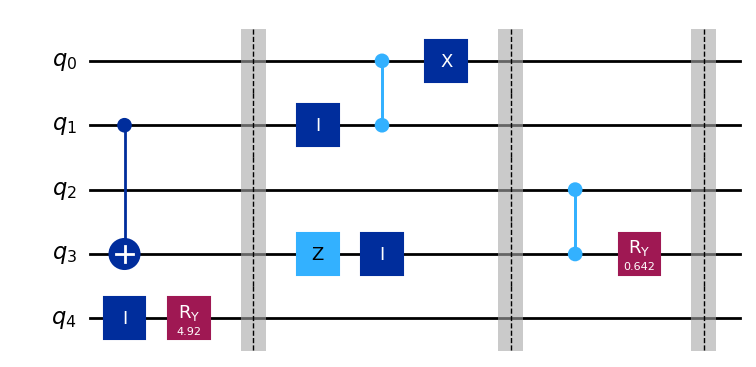

<IPython.core.display.Latex object>

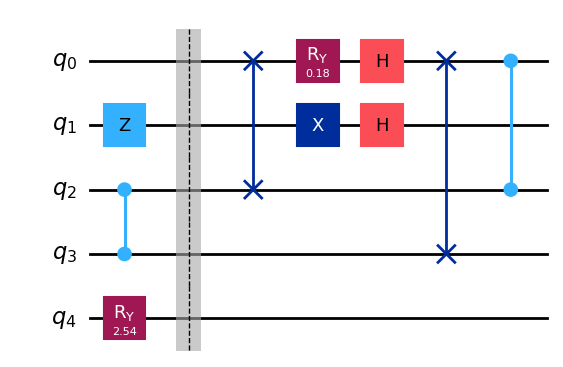

<IPython.core.display.Latex object>

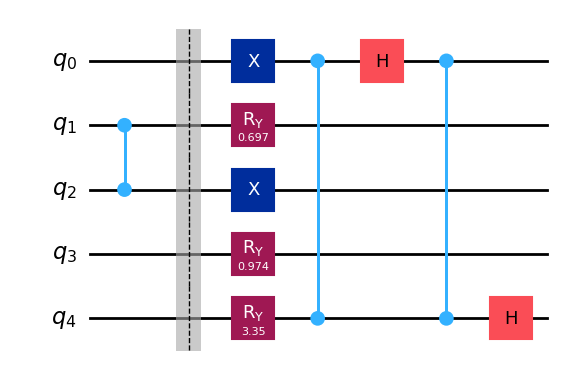

<IPython.core.display.Latex object>

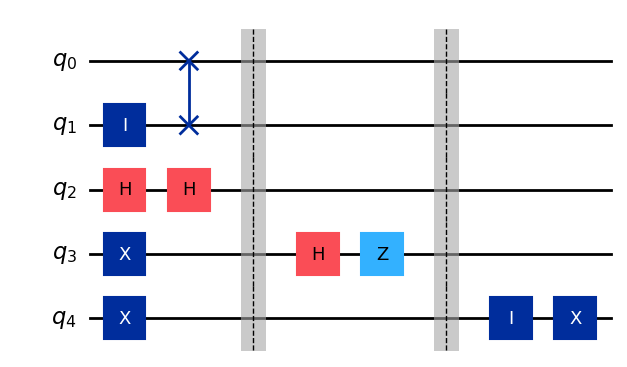

<IPython.core.display.Latex object>

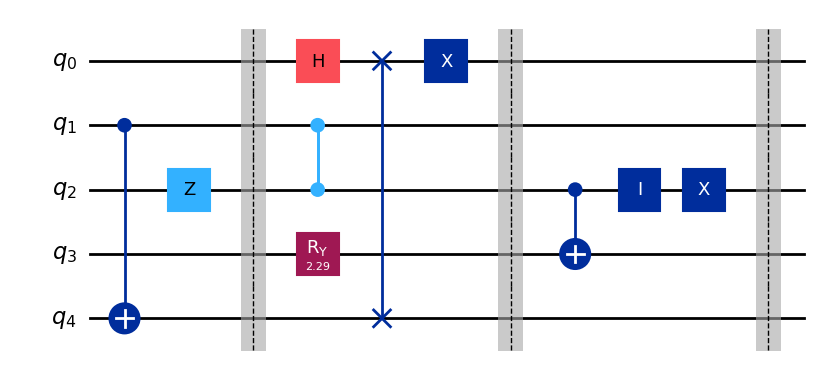

<IPython.core.display.Latex object>

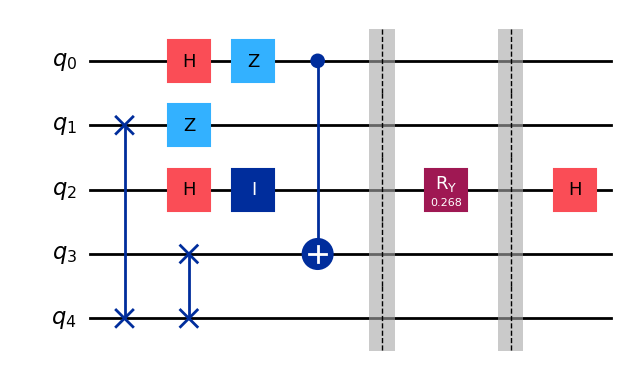

<IPython.core.display.Latex object>

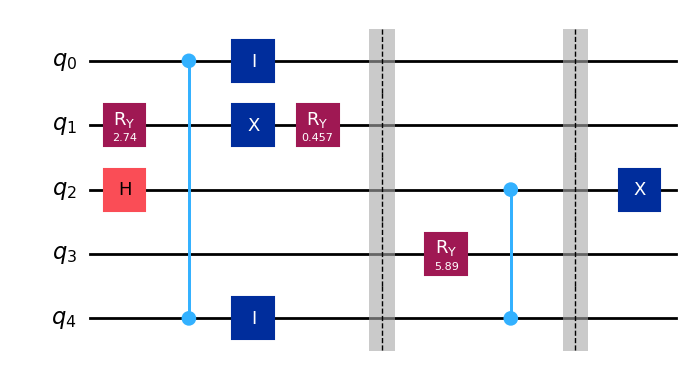

<IPython.core.display.Latex object>

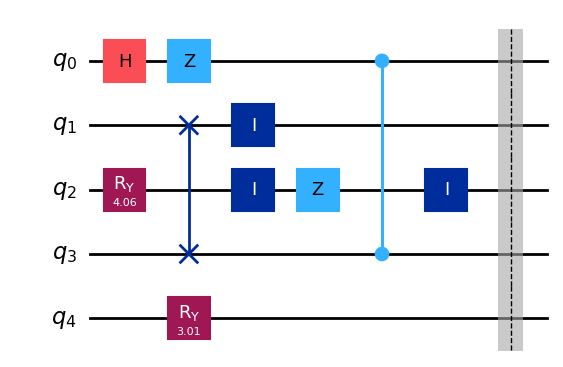

<IPython.core.display.Latex object>

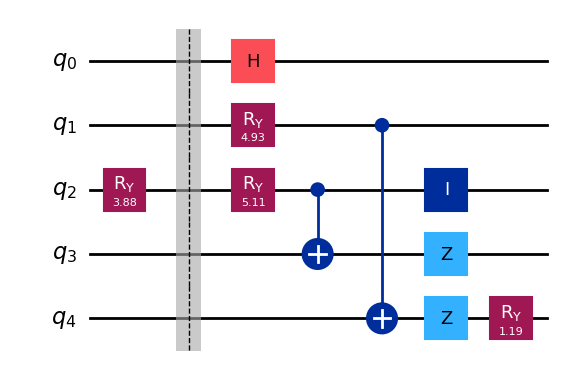

<IPython.core.display.Latex object>

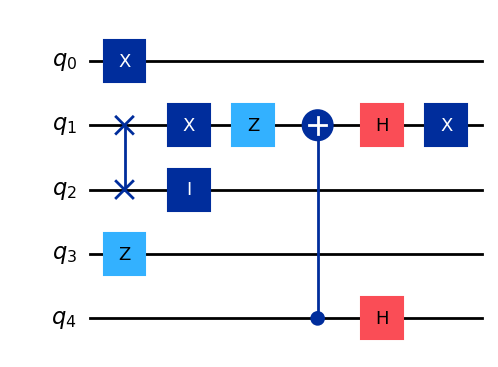

<IPython.core.display.Latex object>

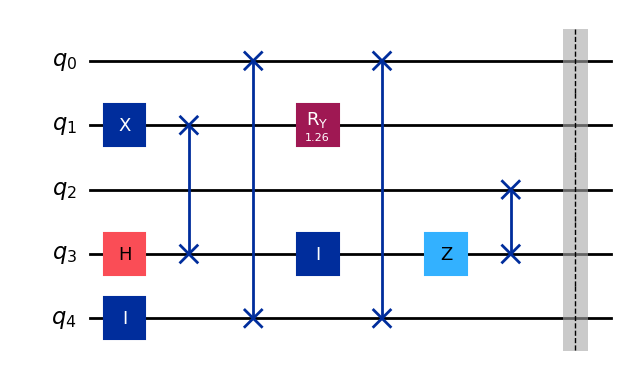

<IPython.core.display.Latex object>

In [207]:
random_qc = RandomCircuit()
for i in range(20):
    qc = random_qc.get_random_circuit(10,5)
    display(qc.draw("mpl"))
    display(Statevector(qc).draw("latex"))